# Wind input against SWAN

`waveray`'s transfer operator can optionally carry stationary wind forcing: the
exponential growth of Komen et al. (1984), integrated along each ray path, plus
(with `agrow=True`) the linear seeding of Cavaleri and Malanotte-Rizzoli (1981). Both
are *input* source terms. What the operator cannot carry is whitecapping or
quadruplet wave-wave interactions — they are nonlinear in the spectral density `E`,
so they cannot live in a linear, frequency-diagonal transfer operator the way
refraction and shoaling can.

That has a direct consequence for how the validation has to be run. `tests/validation/cases.py`
builds SWAN's input with `GEN3 KOMEN DRAG FIT AGROW` for any case that carries wind — a
third-generation wind source — and SWAN raises a **level-2 error** if that is switched on
without quadruplets (`OFF QUAD`) also being turned back on. Force it past that check anyway
(as an early attempt at this validation did) and SWAN never converges: the stationary solver
reports `NOT CONVERGED` and every reported `HSIGN` comes back **zero**. So unlike the
idealised-bathymetry notebook, the wind cases here cannot strip SWAN down to the operator's
own physics — SWAN has to run with its **full** physics (quadruplets + whitecapping +
wind), and waveray is compared against that with only the input term. This notebook is
therefore not measuring "does the operator get refraction and shoaling right" (already shown
in `04_swan_validation_idealised.ipynb`) but "how far does omitting the nonlinear sinks push
the answer, and under what conditions is that omission small enough to be useful."

Requirements: `uv sync --extra notebooks` and a working `docker` daemon with the
`delftwaves/swan:latest` image.

In [1]:
%matplotlib inline
import sys
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")  # repo root (src layout, waveray is installed editable)
sys.path.insert(0, "../tests")  # validation.cases, validation.swan

from validation.cases import plane_beach_case, wind_growth_case, wind_on_swell_case
from validation.swan import swan_image_available

from waveray.bathymetry import LocalGrid
from waveray.operator import build_operator

assert swan_image_available(pull=False), "docker pull delftwaves/swan:latest first"

WORKDIR = Path("_swan_runs_wind")
WORKDIR.mkdir(exist_ok=True)

# Validated palette (dataviz reference instance, light mode) -- matches 02_abrolhos_validation.ipynb
SURFACE = "#fcfcfb"
INK, INK_2, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
BLUE, AQUA, YELLOW, ORANGE = "#2a78d6", "#1baf7a", "#eda100", "#eb6834"
LAND = "#e4e3dd"

mpl.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "figure.dpi": 110,
        "font.size": 10,
        "axes.edgecolor": "#d5d4cf",
        "axes.linewidth": 0.8,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "axes.titlesize": 11,
        "axes.titleweight": "600",
        "axes.titlelocation": "left",
        "axes.titlepad": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.color": INK_MUTED,
        "ytick.color": INK_MUTED,
        "xtick.labelcolor": INK_2,
        "ytick.labelcolor": INK_2,
        "grid.color": "#ecebe6",
        "grid.linewidth": 0.8,
        "legend.frameon": False,
        "lines.linewidth": 2.0,
        "lines.solid_capstyle": "round",
    }
)

# SWAN = orange, waveray(+wind) = blue, waveray(no wind) = muted grey-green throughout.
COLOR_SWAN, COLOR_WRAY, COLOR_NOWIND = ORANGE, BLUE, AQUA


def run_both_wind(case, **build_kwargs):
    """Run SWAN and waveray on a wind case; print (not silently drop) any
    growth-clip warning -- it is informative here, not noise."""
    sw = case.run_swan(WORKDIR / case.name)
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        wr = case.run_waveray(**build_kwargs)
    for w in caught:
        if issubclass(w.category, UserWarning):
            print(f"[UserWarning] {w.message}")
    return sw, wr

## Fetch-limited growth from a calm sea

`wind_growth_case()`: a flat 30 m seabed, **zero boundary energy**, and a uniform 12 m/s
onshore wind. There is no swell here at all -- everything at the targets is wind-sea,
generated locally as the fetch (distance downwind) increases. Because SWAN must run with
quadruplets on for this wind source, it also downshifts the growing spectrum to lower
frequencies as energy cascades through the nonlinear interactions -- the classic
fetch-limited growth curve. waveray's operator has no quadruplet term, so it only carries
the direct wind input (Komen exponential growth plus the AGROW linear seed); with no
downshifting to feed energy toward the (better-forced) low-frequency end, it is expected to
**under-predict** SWAN's fully-forced growth.

findfont: Failed to find font weight 600, now using 700.


[UserWarning] wind growth hit the max_growth=100 ceiling on 0.2% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.


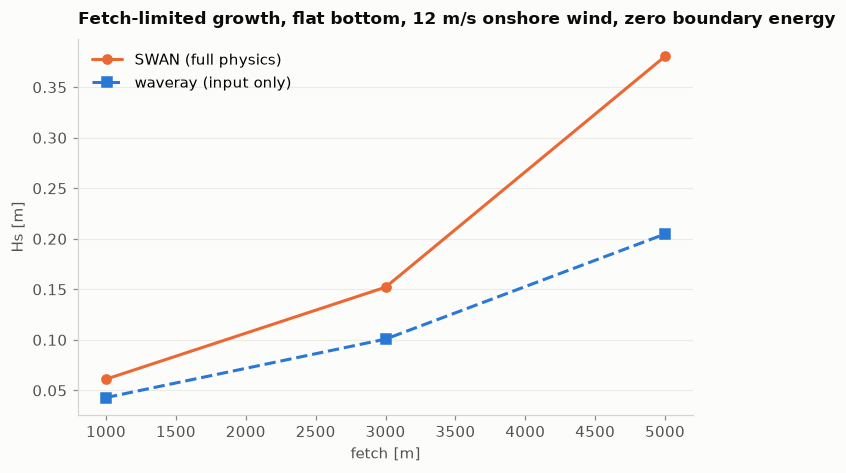

,fetch [m],SWAN Hs [m],waveray Hs [m],waveray/SWAN
0,1000.0,0.0611,0.0429,0.7020
1,3000.0,0.1521,0.1008,0.6624
2,5000.0,0.3806,0.2048,0.5380


In [2]:
case_growth = wind_growth_case(name="windsea")
sw_growth, wr_growth = run_both_wind(case_growth)

fetch = [tx for tx, _ty in case_growth.targets]

fig, ax = plt.subplots(figsize=(6.5, 4.4))
ax.grid(axis="y", zorder=0)
ax.plot(fetch, sw_growth["HSIGN"], "o-", color=COLOR_SWAN, label="SWAN (full physics)", zorder=3)
ax.plot(fetch, wr_growth["HSIGN"], "s--", color=COLOR_WRAY, label="waveray (input only)", zorder=3)
ax.set_xlabel("fetch [m]")
ax.set_ylabel("Hs [m]")
ax.set_title("Fetch-limited growth, flat bottom, 12 m/s onshore wind, zero boundary energy")
ax.legend()
fig.tight_layout()
plt.show()

pd.DataFrame(
    {
        "fetch [m]": fetch,
        "SWAN Hs [m]": sw_growth["HSIGN"],
        "waveray Hs [m]": wr_growth["HSIGN"],
        "waveray/SWAN": wr_growth["HSIGN"] / sw_growth["HSIGN"],
    }
).round(4)

In [3]:
ratio_growth = wr_growth["HSIGN"] / sw_growth["HSIGN"]
print(
    f"both models grow with fetch: SWAN {np.all(np.diff(sw_growth['HSIGN']) > 0)}, "
    f"waveray {np.all(np.diff(wr_growth['HSIGN']) > 0)}"
)
print(
    f"waveray/SWAN ratio: {np.round(ratio_growth, 3)} "
    f"(range {ratio_growth.min():.2f}-{ratio_growth.max():.2f})"
)

both models grow with fetch: SWAN True, waveray True
waveray/SWAN ratio: [0.702 0.662 0.538] (range 0.54-0.70)


## Wind on swell: the realistic downscale

`wind_on_swell_case()` is the configuration this operator is actually meant for: a plane
beach carrying a JONSWAP swell boundary (as in the idealised notebook) *plus* a 12 m/s
onshore wind blowing over the same short nearshore fetch. SWAN again needs its full physics
to carry the wind, so it is compared against three series:

- **SWAN**, full physics (swell propagation + wind generation + quadruplets + whitecapping);
- **waveray, with wind** -- the operator built with `wind=(12.0, 270.0), agrow=True`;
- **waveray, no wind** -- the same swell-only propagation as the idealised notebook
  (`plane_beach_case(name="ref", dpm=270.0).run_waveray()`), included as a reference for how
  much the wind term alone adds.

waveray has no dissipation to balance the wind input, so it should sit *above* both the
no-wind reference (wind must add energy) and SWAN (which also loses energy to whitecapping)
-- and the gap to SWAN should widen as the fetch available for wind growth grows relatively
larger toward the shallow end.

[UserWarning] wind growth hit the max_growth=100 ceiling on 0.9% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
[UserWarning] wind growth hit the max_growth=100 ceiling on 3.1% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.
[UserWarning] wind growth hit the max_growth=100 ceiling on 3.8% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.


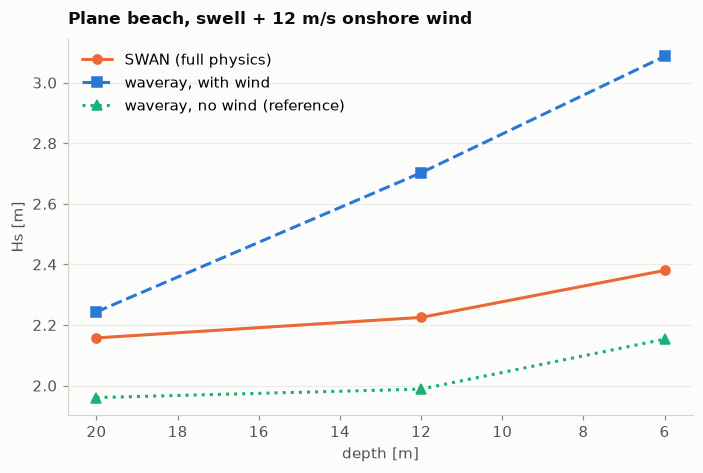

,depth [m],SWAN Hs [m],waveray+wind Hs [m],waveray no-wind Hs [m],waveray+wind / SWAN
0,20.0,2.1574,2.2434,1.9604,1.0399
1,12.0,2.2250,2.7025,1.9883,1.2146
2,6.0,2.3802,3.0868,2.1532,1.2969


In [4]:
case_windswell = wind_on_swell_case(name="windswell")
sw_windswell, wr_windswell = run_both_wind(case_windswell)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")  # no wind on the reference case -> nothing to catch
    wr_nowind = plane_beach_case(name="ref", dpm=270.0).run_waveray()

depths_windswell = [
    case_windswell.grid.sample_depth(np.array([tx]), np.array([ty]))[0]
    for tx, ty in case_windswell.targets
]

fig, ax = plt.subplots(figsize=(6.5, 4.4))
ax.grid(axis="y", zorder=0)
ax.plot(
    depths_windswell,
    sw_windswell["HSIGN"],
    "o-",
    color=COLOR_SWAN,
    label="SWAN (full physics)",
    zorder=3,
)
ax.plot(
    depths_windswell,
    wr_windswell["HSIGN"],
    "s--",
    color=COLOR_WRAY,
    label="waveray, with wind",
    zorder=3,
)
ax.plot(
    depths_windswell,
    wr_nowind["HSIGN"],
    "^:",
    color=COLOR_NOWIND,
    label="waveray, no wind (reference)",
    zorder=3,
)
ax.invert_xaxis()
ax.set_xlabel("depth [m]")
ax.set_ylabel("Hs [m]")
ax.set_title("Plane beach, swell + 12 m/s onshore wind")
ax.legend()
fig.tight_layout()
plt.show()

pd.DataFrame(
    {
        "depth [m]": depths_windswell,
        "SWAN Hs [m]": sw_windswell["HSIGN"],
        "waveray+wind Hs [m]": wr_windswell["HSIGN"],
        "waveray no-wind Hs [m]": wr_nowind["HSIGN"],
        "waveray+wind / SWAN": wr_windswell["HSIGN"] / sw_windswell["HSIGN"],
    }
).round(4)

In [5]:
ratio_windswell = wr_windswell["HSIGN"] / sw_windswell["HSIGN"]
adds_energy = np.all(wr_windswell["HSIGN"] > wr_nowind["HSIGN"])
departure_grows = np.all(np.diff(ratio_windswell) >= 0)
print(f"wind adds energy over the no-wind reference at every target: {adds_energy}")
print(
    f"waveray/SWAN ratio: {np.round(ratio_windswell, 3)} "
    f"(range {ratio_windswell.min():.2f}-{ratio_windswell.max():.2f})"
)
print(f"departure from SWAN grows monotonically shoreward: {departure_grows}")

wind adds energy over the no-wind reference at every target: True
waveray/SWAN ratio: [1.04  1.215 1.297] (range 1.04-1.30)
departure from SWAN grows monotonically shoreward: True


## The runaway demonstration: why `max_growth` exists

The Komen growth term integrates a rate `B` along the ray path; the net gain is
`exp(integral B ds)`. In deep water the group velocity `cg ~ g / (4*pi*f)` gets *smaller*
as frequency increases, so a ray at high frequency spends longer covering the same fetch --
its growth exponent accumulates for longer. SWAN keeps this in check with quadruplets
(downshifting energy away) and whitecapping (dissipating it); a linear operator has neither,
so wind input on its own really is unbounded on a long enough high-frequency fetch -- this
is not a numerical artefact, it is what "input only" structurally means.

`build_operator`'s `max_growth` parameter (default 100 -- a hundredfold energy gain per ray)
floors the growth exponent so the operator stays finite, and raises a `UserWarning` reporting
what fraction of rays hit the ceiling. The cell below builds the same flat-bottom wind case
directly with `waveray.operator.build_operator`, once with `max_growth=None` and once with
the default `max_growth=100.0`, over a frequency range (0.05-1.0 Hz) wide enough to include
poorly-resolved high frequencies, and plots the resulting wind-generated spectrum `E(f)` on
a log axis.

In [6]:
length = 15_000.0
halfwidth = 4_000.0
nx, ny = 61, 41
x = np.linspace(0.0, length, nx)
y = np.linspace(-halfwidth, halfwidth, ny)
depth = np.full((ny, nx), 30.0)
grid = LocalGrid(x=x, y=y, depth=depth)

freqs = np.linspace(0.05, 1.0, 25)
dirs = np.arange(0.0, 360.0, 10.0)
dd = float(dirs[1] - dirs[0])
target_xy = (length - 500.0, 0.0)
boundary_xy = np.array([[0.0, -1_000.0], [0.0, 1_000.0]])

ops = {}
for max_growth in (None, 100.0):
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        ops[max_growth] = build_operator(
            grid,
            target_xy,
            boundary_xy,
            freqs,
            dirs,
            cf_jonswap=None,
            wind=(15.0, 270.0),
            agrow=True,
            max_growth=max_growth,
        )
    label = (
        "unbounded (max_growth=None)"
        if max_growth is None
        else f"capped (max_growth={max_growth:g})"
    )
    if caught:
        for w in caught:
            print(f"[{label}] [UserWarning] {w.message}")
    else:
        print(f"[{label}] no warning raised")

e_unbounded = ops[None].E0.sum(axis=1) * dd
e_capped = ops[100.0].E0.sum(axis=1) * dd
print(
    f"\nE(f) at the highest frequency ({freqs[-1]:.2f} Hz): "
    f"unbounded = {e_unbounded[-1]:.3e} m^2/Hz, capped = {e_capped[-1]:.3e} m^2/Hz"
)

[unbounded (max_growth=None)] no warning raised


[capped (max_growth=100)] [UserWarning] wind growth hit the max_growth=100 ceiling on 27.5% of rays. Wind input alone is unbounded (SWAN balances it with whitecapping and quadruplets, which a linear operator cannot carry), so these paths are outside the regime where it is meaningful: shorten the domain, drop the high-frequency bins, or reduce the wind.

E(f) at the highest frequency (1.00 Hz): unbounded = 3.499e+151 m^2/Hz, capped = 7.636e+00 m^2/Hz


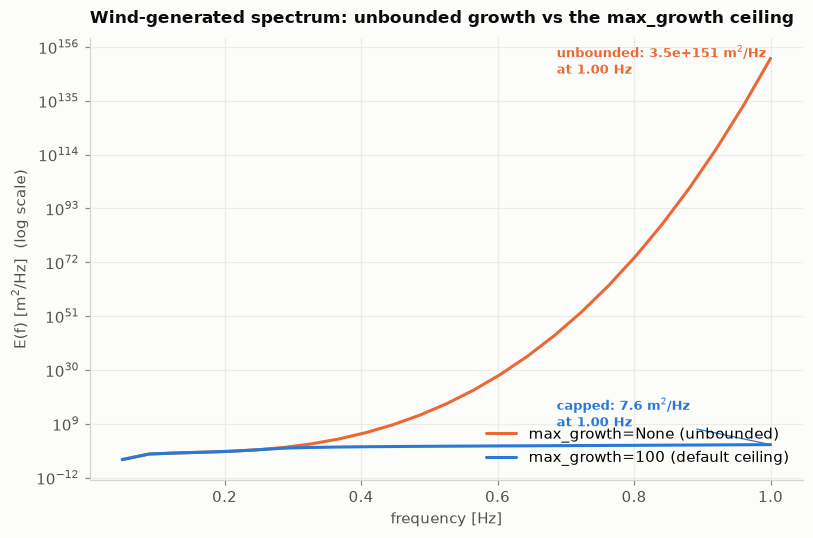

unbounded growth spans 156 orders of magnitude across the resolved frequency range; the capped run spans 5.8.


In [7]:
fig, ax = plt.subplots(figsize=(7.5, 5.0))
ax.grid(zorder=0, which="both")
ax.plot(freqs, e_unbounded, color=COLOR_SWAN, label="max_growth=None (unbounded)", zorder=3)
ax.plot(freqs, e_capped, color=COLOR_WRAY, label="max_growth=100 (default ceiling)", zorder=3)
ax.set_yscale("log")
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel("E(f) [m$^2$/Hz]  (log scale)")
ax.set_title("Wind-generated spectrum: unbounded growth vs the max_growth ceiling")
ax.annotate(
    f"unbounded: {e_unbounded[-1]:.1e} m$^2$/Hz\nat {freqs[-1]:.2f} Hz",
    xy=(freqs[-1], e_unbounded[-1]),
    xytext=(-140, -10),
    textcoords="offset points",
    color=COLOR_SWAN,
    fontsize=8.5,
    fontweight="600",
    arrowprops=dict(arrowstyle="-", color=COLOR_SWAN, lw=0.8),
)
ax.annotate(
    f"capped: {e_capped[-1]:.1f} m$^2$/Hz\nat {freqs[-1]:.2f} Hz",
    xy=(freqs[-1], e_capped[-1]),
    xytext=(-140, 12),
    textcoords="offset points",
    color=COLOR_WRAY,
    fontsize=8.5,
    fontweight="600",
    arrowprops=dict(arrowstyle="-", color=COLOR_WRAY, lw=0.8),
)
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

print(
    f"unbounded growth spans {np.log10(e_unbounded.max() / e_unbounded.min()):.0f} "
    f"orders of magnitude across the resolved frequency range; "
    f"the capped run spans {np.log10(e_capped.max() / e_capped.min()):.1f}."
)

## Conclusions

Wind input in waveray is an *input-only* term: it has no quadruplets to downshift energy
and no whitecapping to dissipate it, because neither can be written as a linear,
frequency-diagonal operator. Two consequences follow directly, and both are quantified
above:

- **Fetch-limited wind-sea generation** is where omitting the nonlinear sinks costs the
  most: without downshifting, waveray systematically under-predicts SWAN's fully-forced
  growth (see the ratio printed above). This case is a stress test, not the intended use.
- **Wind added to an existing swell over a short nearshore fetch** is the intended use, and
  the departure from SWAN there is much smaller and grows gradually with fetch (see the
  ratio printed above) -- because most of the target energy is still the swell that both
  models propagate the same way, and the wind-generated fraction is small enough that the
  missing sinks do not have time to matter.
- **Left unbounded, wind input is not merely biased but structurally unstable** on long,
  poorly-resolved high-frequency fetches, which is exactly why `max_growth` exists and
  defaults on.

**When to switch wind on:** short nearshore fetches where the boundary swell dominates the
target energy and the frequency grid stays inside the range that stays well-resolved (per
the `04` notebook's `FREQS`, roughly 0.04-0.4 Hz) -- there the correction is bounded and
directionally correct. **When not to:** fetch-limited wind-sea generation from near-zero
energy, or any case reaching high frequencies over a long fetch, where the missing
quadruplet/whitecapping balance dominates the answer and the `growth_clipped_fraction`
warning is telling you the operator is being asked to do something a linear model
structurally cannot.